In [2]:
# Run this cell for missing installations!
%pip install pandas matplotlib seaborn numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


./SEM_2026\d_73.csv
Remaining rows (data points): 22353
    Tick
0  12396
1  12702
2  12752
3  12802
4  12852

Missing values per column:
Tick        0
Throttle    0
Speed       0
Current     0
Voltage     0
TimePlot    0
dtype: int64

Total energy consumed: 269000.9401171078 J or 0.07472248336586329 kWh
Total time:
minutes: 21, seconds: 18.96

Efficiency: 102.58 km/kWh


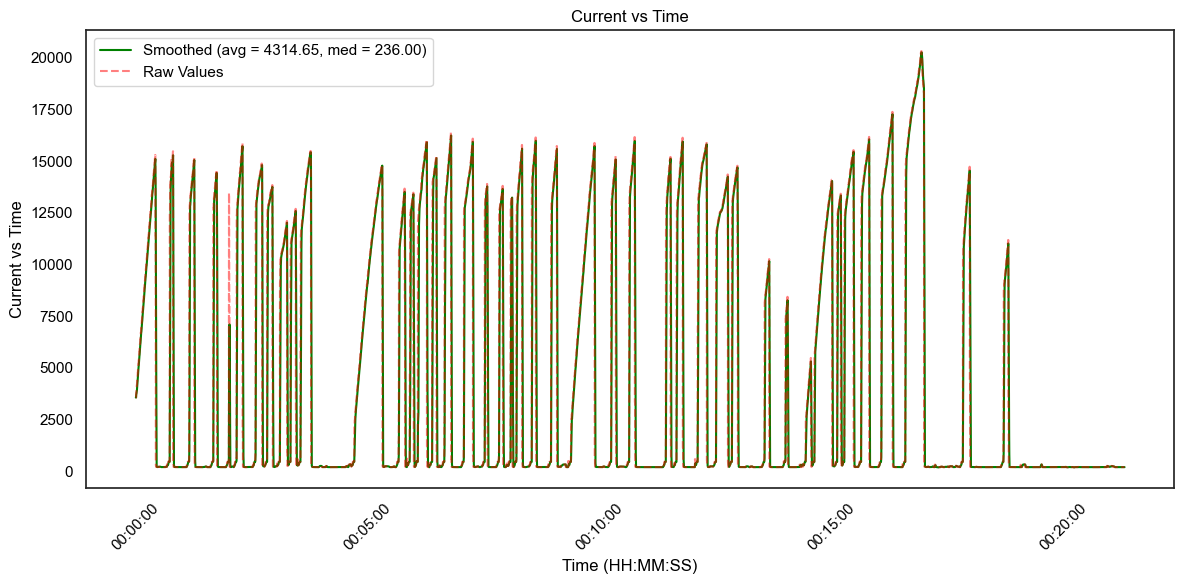

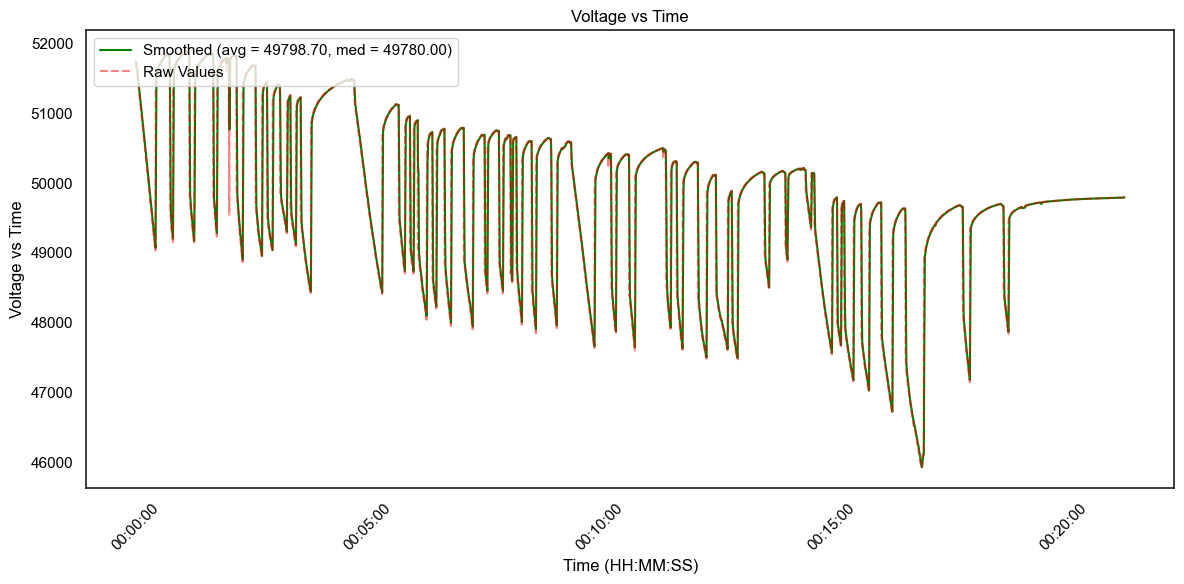

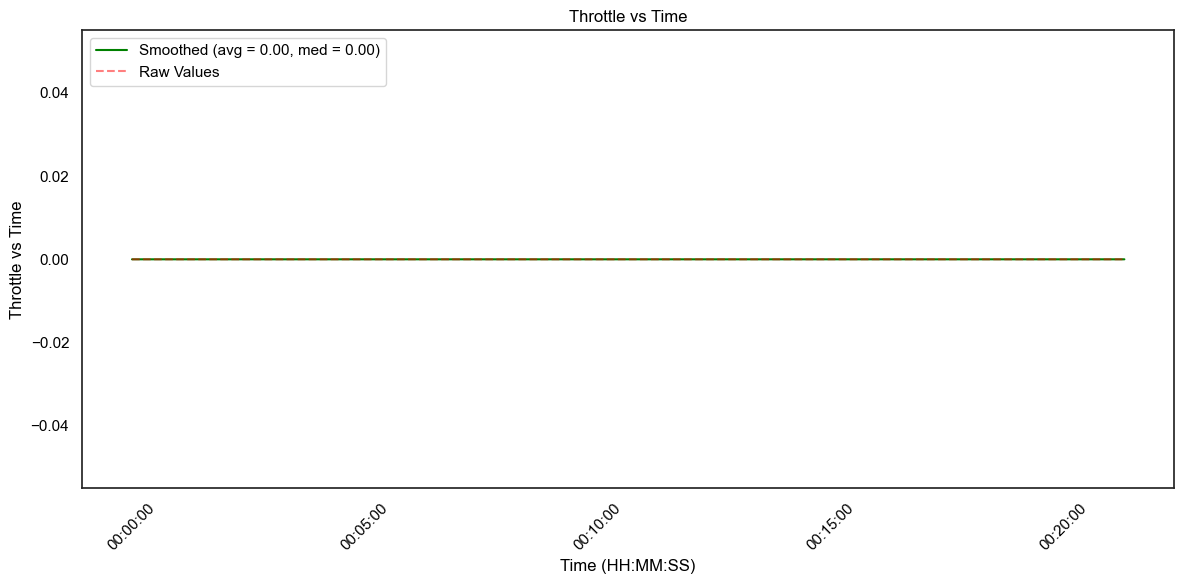

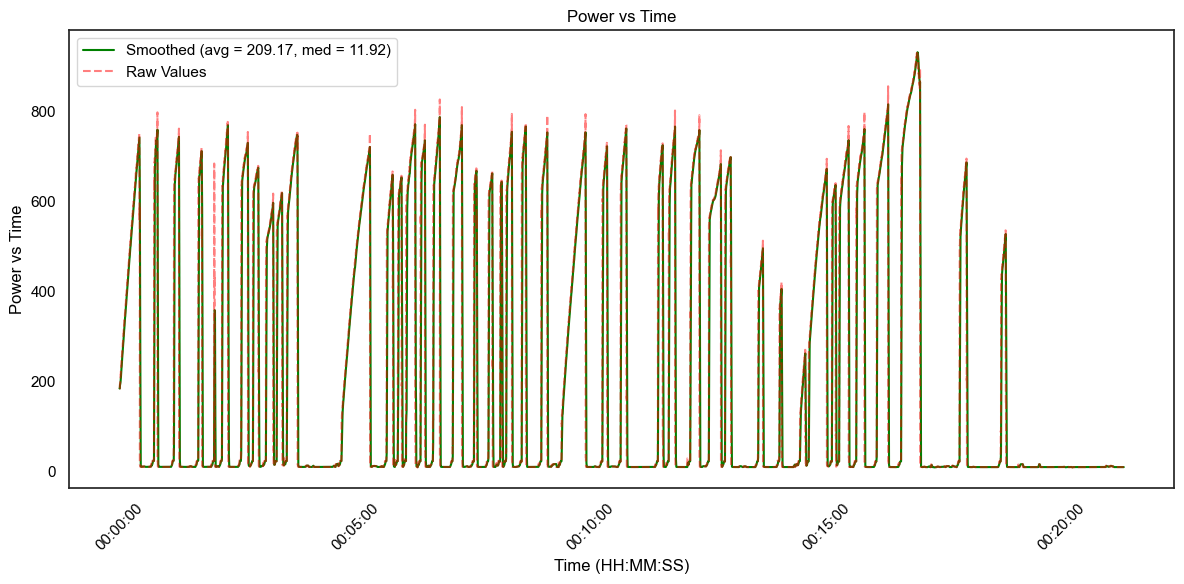

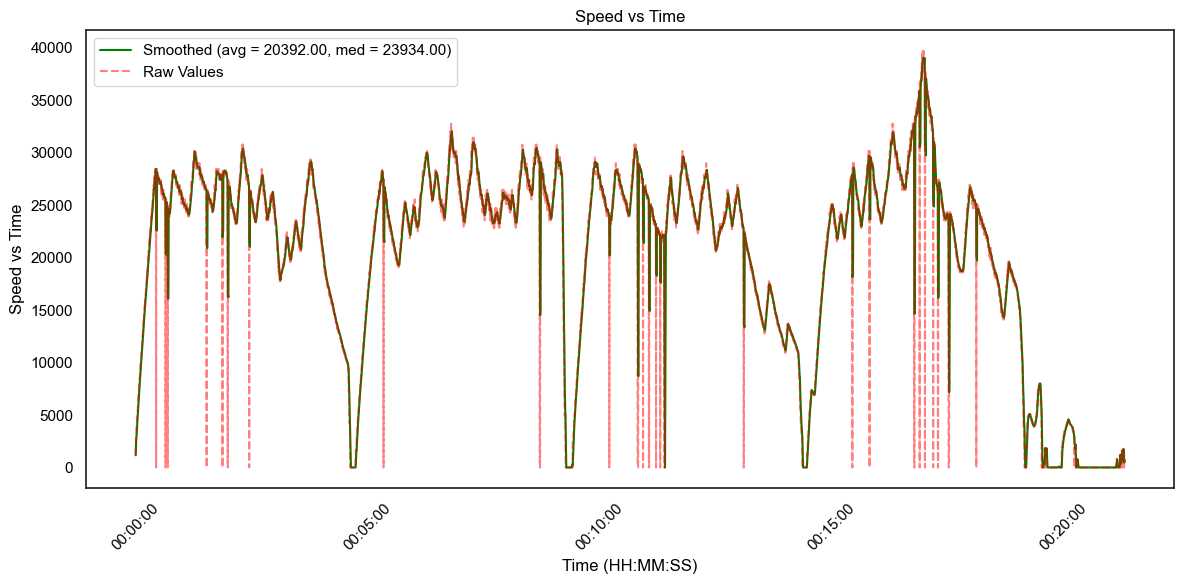

In [9]:
# Telemetry data plotting
# Last updated: April 8, 2026
# By: Daniel
# ** Execute installation (previous cell) if imports are missing! **
# 1. Graphs relevant statstics
# 2. Calculates overall time, and efficiency
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import matplotlib.dates as mdates
import os
import NulRemover

sns.set(style='white')  # light background
# data_folder = f'./{date}/'
# file = f'{date}-{time}.csv'
# path = os.path.join(data_folder, file)
data_folder = './SEM_2026'
num = 73 # dataset number for processing
file = f'd_{num}.csv'
path = os.path.join(data_folder, file)
print(path)
delimiter = ',' # seperator used in data
start_row = 0 # data startpoint
distance = 15.33/2 # Distance in km, used for efficiency calculation
Ticks = True  # Set to False if did not correct ticks
start_throttle = 0.1  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers

start_ms = 0
test_duration = 4 * 60000 # 60 * 1000 *run time len

# Load and clean data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
# data = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
# data['Tick'] = (data['Tick'].apply(clean_cell))

data = pd.read_csv(path, delimiter = delimiter, skiprows = start_row)
data.columns = data.columns.str.strip()

# Remove rows before the first throttle
if throttle_start_flag:
    start_throttle_index = data[data['Throttle'] >= start_throttle].index.min()
    data = data.iloc[start_throttle_index:]
# Truncate data 
if start_ms != 0:
    data = data[data['Tick'] >= start_ms]
    data = data[data['Tick'] <= start_ms + test_duration]
    # data = data.iloc[index:]
print("Remaining rows (data points):", len(data))
print(data[['Tick']].head())


# Convert Tick to time
if Ticks:
    data['Tick'] = data['Tick'].astype(int)  # Ensure Tick is int
    # data['Time'] = pd.to_timedelta(data['Tick'], unit='ms') # Old method
    # data['TimePlot'] = pd.Timestamp("2023-01-01") + data['Time']
    data['Tick'] = data['Tick'] - data['Tick'].iloc[0]  # start at 0 ms
    data['TimePlot'] = pd.Timestamp("2023-01-01") + pd.to_timedelta(data['Tick'], unit='ms')
else:
    data['TimePlot'] = range(len(data))

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Add power calculation
if 'Current' in data.columns and 'Voltage' in data.columns:
    data['Power'] = (data['Current'] / 1e3) * (data['Voltage']/1e3)

# Add total energy calculation
if 'Power' in data.columns:
    energy_joules = np.trapezoid(data['Power'], x = data['Tick'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_joules} J or {energy_kWh} kWh")

# Calculate time
ms = data['Tick'].iloc[-1] - data['Tick'].iloc[0]
seconds = ms / 1000 % 60
minutes = int(ms / 60000)
print("Total time:")
if minutes > 0:
    print(f"minutes: {minutes}", end = ", ")
print(f"seconds: {seconds:.2f}" )

# Calculate efficiency
efficiency = distance/energy_kWh  # km per kWh
print(f"\nEfficiency: {efficiency:.2f} km/kWh")

# Columns to visualize
columns_to_plot = ['Current', 'Voltage','Throttle','Power', 'Speed']
# data.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data.columns:
        x = data['TimePlot']
        y = data[col]
        y_smooth = y.rolling(window = 20, min_periods = 1).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y, nan_policy = 'omit')
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize = (12, 6))

        # Use numpy arrays for plotting 
        # Smoothed line
        ax.plot(x, y_smooth, color = 'green', label = f'Smoothed (avg = {avg:.2f}, med = {med:.2f})')

        # Raw dashed line
        ax.plot(x,y, linestyle = '--', color = 'red', alpha = 0.5, label = 'Raw Values')

        # Outliers as blue dots
        if plot_outliers:
            ax.scatter(x[outliers], y[outliers], color = 'blue', label = 'Outliers')

        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis = 'x', colors = 'black', rotation = 45)
        ax.tick_params(axis = 'y', colors = 'black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc = 'upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")


./SEM_2026\d_48.csv
Data for second run:
Columns: Index(['Tick', 'Throttle', 'Speed', 'Current', 'Voltage'], dtype='object')
Data points: 15777

Missing values per column:
Tick        0
Throttle    0
Speed       0
Current     0
Voltage     0
TimePlot    0
dtype: int64

Total energy consumed: 99098.312290304 J or 0.02752730896952889 kWh

Efficiency: 278.45 km/kWh


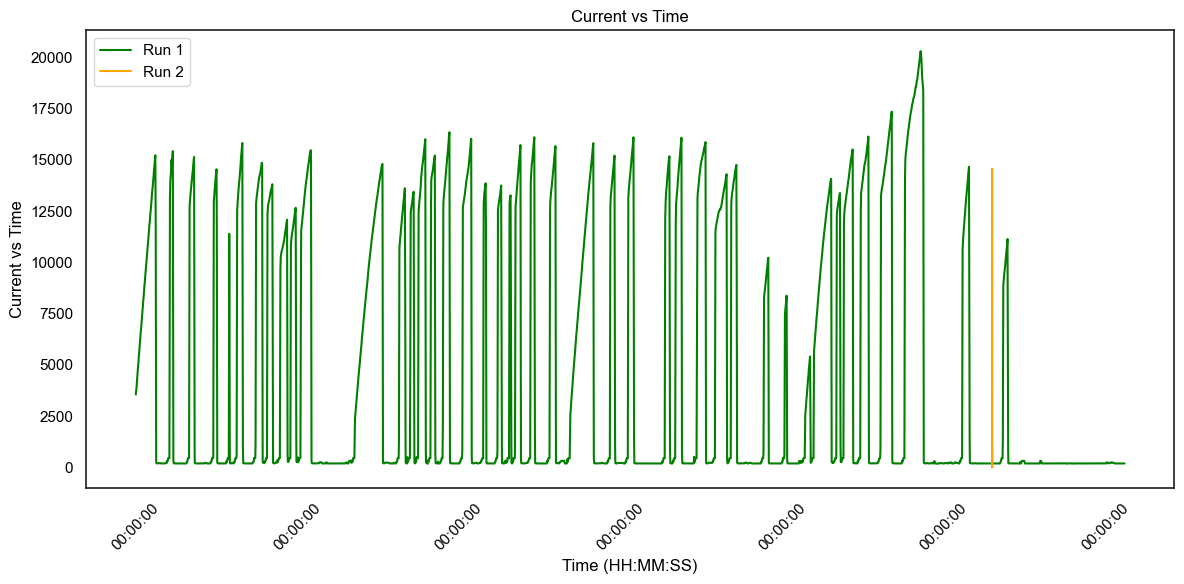

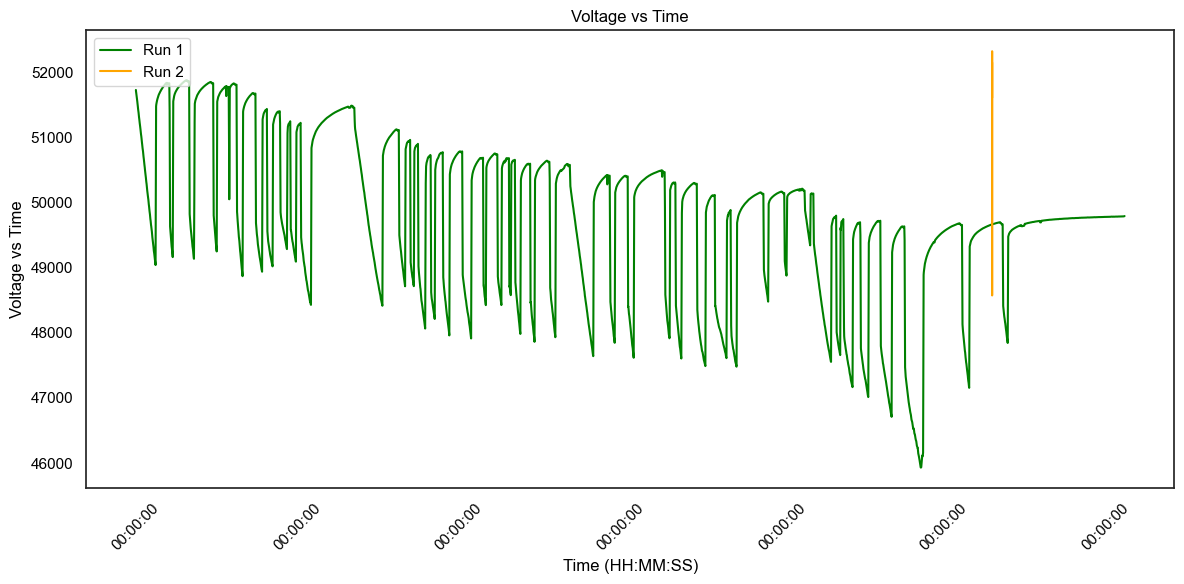

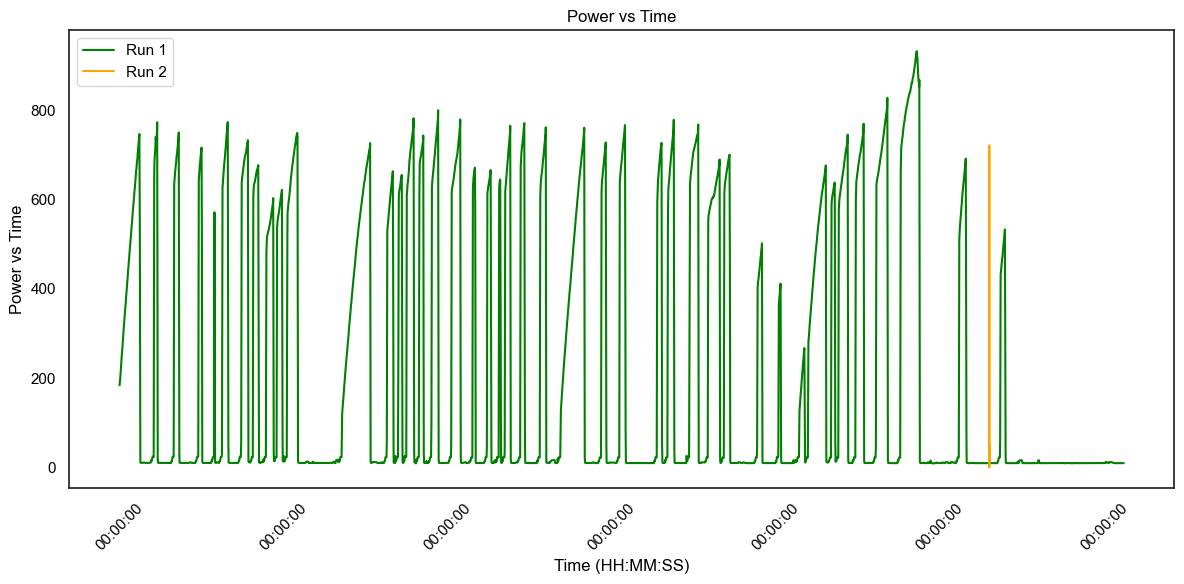

In [ ]:
# Overlay power consumption of a second run
# Compares the second run to the first run loaded above
# Last updated: April 8, 2026
# By: Daniel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import matplotlib.dates as mdates
import os
import NulRemover

sns.set(style='white')  # light background
# data_folder = f'./{date}/'
# file = f'{date}-{time}.csv'
# path = os.path.join(data_folder, file)
data_folder = './SEM_2026'
num = 48 # Insert 2nd dataset number to compare here
file = f'd_{num}.csv'
path = os.path.join(data_folder, file)
print(path)
delimiter = ',' # seperator used 
start_rows = 0 # data startpoint
distance = 15.33/2 # Distance in km, used for efficiency calculation
Ticks = False  # Set to False if did not correct ticks
start_throttle = 0.1  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers

# Run to clean the data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
#data_2 = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
#data_2['Tick'] = (data_2['Tick'].apply(clean_cell))

data_2 = pd.read_csv(path, delimiter = delimiter, skiprows = start_row)
data_2.columns = data_2.columns.str.strip()
print("Data for second run:")
print(f"Columns: {data_2.columns}")
print(f"Data points: {len(data_2)}")

# Remove rows before the first throttle > start_throttle
if throttle_start_flag:
    start_throttle_index = data_2[data_2['Throttle'] >= start_throttle].index.min()
    data_2 = data_2.iloc[start_throttle_index:]

# Convert Tick to time
data_2['Tick'] = data_2['Tick'].astype(int)  # Ensure Tick is int
data_2['Tick'] = data_2['Tick'] - data_2['Tick'].iloc[0]  # start at 0 ms
data_2['TimePlot'] = pd.Timestamp("2023-01-01") + pd.to_timedelta(data_2['Tick'], unit='ms')

# Check for missing values
print("\nMissing values per column:")
print(data_2.isnull().sum())

# Add power calculation
if 'Current' in data_2.columns and 'Voltage' in data_2.columns:
    data_2['Power'] = (data_2['Current'] / 1e3) * (data_2['Voltage'] / 1e3)

# Add total energy calculation
if 'Power' in data_2.columns:
    energy_joules = np.trapezoid(data_2['Power'], x = data_2['Tick'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_joules} J or {energy_kWh} kWh")

# Calculate time
ms = data['Tick'].iloc[-1] - data['Tick'].iloc[0]
seconds = ms / 1000 % 60
minutes = int(ms / 60000)
print("Total time:")
if minutes > 0:
    print(f"minutes: {minutes}", end = ", ")
print(f"seconds: {seconds:.2f}" )

# Calculate efficiency
efficiency = distance / energy_kWh  # km / kWh
print(f"\nEfficiency: {efficiency:.2f} km/kWh")

# Columns to visualize
columns_to_plot = ['Current','Voltage','Power']

# Plot each column
for col in columns_to_plot:
    if col in data_2.columns:
        x_1 = data['TimePlot']
        y_1 = data[col]
        y_1_smooth = y_1.rolling(window = 10, min_periods = 1).mean()
        x_2 = data_2['TimePlot']
        y_2 = data_2[col]
        y_2_smooth = y_2.rolling(window = 10, min_periods = 1).mean()

        # Stats
        avg = y_1.mean()
        med = y_1.median()

        # Outliers (Z-score method)
        z_scores = zscore(y_1, nan_policy = 'omit')
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize = (12, 6))

        # Use numpy arrays for plotting with only first dimension (this is weird)
        # Smoothed line
        ax.plot(x_1, y_1_smooth, color = 'green', label = f'Run 1')
        ax.plot(x_2, y_2_smooth, color = 'orange', label = f'Run 2')

        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color = 'black')
        ax.set_ylabel(f"{col} vs Time", color = 'black')
        ax.set_title(f"{col} vs Time", color = 'black')
        ax.tick_params(axis = 'x', colors = 'black', rotation = 45)
        ax.tick_params(axis = 'y', colors = 'black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")